In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter

In [3]:
path = 'C:/Users/WoojaeYang/Desktop/DCR/'

main4 = pd.read_csv(f'{path}data/main4.csv')
main4.head(20)

,SN_KEY,SEER_GRP,AGE,FDX,INDEX_Y,INDEX_MDY,STATIN,DTH,DREGDATE,INDEX_AGE,SIDO_CD,CALC_CTRB_VTILE_FD,DYS,RTX,SUR,DTH_MDY,TIME,SIDO,CALC,AGEGP
0,a3,2,39,2012-09-15,2017,2017-09-15,1,0,NaN,44,44.0,10.0,1,0,1,18992,1568,2.0,2,1
1,a6,9,78,2012-12-19,2017,2017-12-19,0,1,2019-02-03,83,NaN,NaN,0,1,1,17930,411,NaN,2,2
2,a8,2,59,2012-05-12,2017,2017-05-12,1,0,NaN,64,NaN,NaN,1,0,1,18992,1694,NaN,2,1
3,a11,7,53,2012-12-28,2017,2017-12-28,0,1,2019-05-05,58,NaN,NaN,0,1,0,18021,493,NaN,2,1
4,a14,2,70,2012-12-28,2017,2017-12-28,1,0,NaN,75,NaN,NaN,1,0,1,18992,1464,NaN,2,2
5,a15,1,60,2012-08-11,2017,2017-08-11,1,1,2017-09-12,65,NaN,NaN,1,1,1,17421,32,NaN,2,1
6,a17,2,51,2012-05-07,2017,2017-05-07,1,0,NaN,56,NaN,NaN,1,0,1,18992,1699,NaN,2,1
7,a18,1,51,2012-12-28,2017,2017-12-28,1,0,NaN,56,41.0,10.0,1,0,1,18992,1464,2.0,2,1
8,a19,1,50,2012-08-04,2017,2017-08-04,0,1,2018-11-08,55,NaN,NaN,1,1,1,17843,461,NaN,2,1
9,a21,2,68,2012-08-11,2017,2017-08-11,0,1,2018-05-30,73,NaN,NaN,0,1,1,17681,292,NaN,2,2


In [6]:
main4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SN_KEY              241 non-null    object 
 1   SEER_GRP            241 non-null    int64  
 2   AGE                 241 non-null    int64  
 3   FDX                 241 non-null    object 
 4   INDEX_Y             241 non-null    int64  
 5   INDEX_MDY           241 non-null    object 
 6   STATIN              241 non-null    int64  
 7   DTH                 241 non-null    int64  
 8   DREGDATE            105 non-null    object 
 9   INDEX_AGE           241 non-null    int64  
 10  SIDO_CD             131 non-null    float64
 11  CALC_CTRB_VTILE_FD  131 non-null    float64
 12  DYS                 241 non-null    int64  
 13  RTX                 241 non-null    int64  
 14  SUR                 241 non-null    int64  
 15  DTH_MDY             241 non-null    int64  
 16  TIME    

In [8]:
main4.isnull().sum()

SN_KEY                  0
SEER_GRP                0
AGE                     0
FDX                     0
INDEX_Y                 0
INDEX_MDY               0
STATIN                  0
DTH                     0
DREGDATE              136
INDEX_AGE               0
SIDO_CD               110
CALC_CTRB_VTILE_FD    110
DYS                     0
RTX                     0
SUR                     0
DTH_MDY                 0
TIME                    0
SIDO                  110
CALC                    0
AGEGP                   0
dtype: int64

In [10]:
main4.describe()

,SEER_GRP,AGE,INDEX_Y,STATIN,DTH,INDEX_AGE,SIDO_CD,CALC_CTRB_VTILE_FD,DYS,RTX,SUR,DTH_MDY,TIME,SIDO,CALC,AGEGP
count,241.000000,241.000000,241.0,241.000000,241.000000,241.000000,131.000000,131.000000,241.000000,241.000000,241.000000,241.000000,241.000000,131.000000,241.000000,241.000000
mean,3.091286,57.601660,2017.0,0.278008,0.435685,62.601660,32.687023,6.129771,0.278008,0.394191,0.684647,18564.692946,1202.120332,1.748092,1.775934,1.369295
std,3.221019,11.817318,0.0,0.448950,0.496878,11.817318,13.970344,3.216297,0.448950,0.489693,0.465623,551.403668,564.060929,0.435775,0.417834,0.483618
min,1.000000,32.000000,2017.0,0.000000,0.000000,37.000000,11.000000,0.000000,0.000000,0.000000,0.000000,17421.000000,32.000000,1.000000,1.000000,1.000000
25%,1.000000,49.000000,2017.0,0.000000,0.000000,54.000000,18.500000,3.000000,0.000000,0.000000,0.000000,18021.000000,645.000000,1.500000,2.000000,1.000000
50%,1.000000,56.000000,2017.0,0.000000,0.000000,61.000000,41.000000,6.000000,0.000000,0.000000,1.000000,18992.000000,1517.000000,2.000000,2.000000,1.000000
75%,2.000000,66.000000,2017.0,1.000000,1.000000,71.000000,44.000000,9.000000,1.000000,1.000000,1.000000,18992.000000,1664.000000,2.000000,2.000000,2.000000
max,9.000000,91.000000,2017.0,1.000000,1.000000,96.000000,48.000000,10.000000,1.000000,1.000000,1.000000,18992.000000,1820.000000,2.000000,2.000000,2.000000


# 1. Kaplan-Meier

## 1-1) Graph

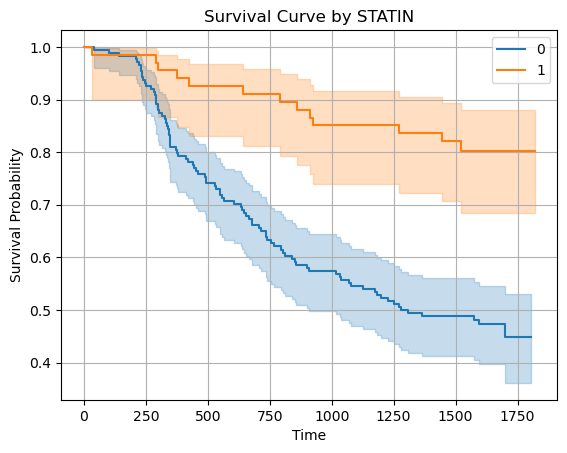

In [12]:
kmf = KaplanMeierFitter()

for label, grp in main4.groupby('STATIN'):
    kmf.fit(grp['TIME'], grp['DTH'], label=label)
    kmf.plot_survival_function()

plt.title("Survival Curve by STATIN")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

## 1-2) Table

In [14]:
kmf_statin_0 = KaplanMeierFitter()
kmf_statin_1 = KaplanMeierFitter()

In [16]:
statin0_df = main4[main4['STATIN'] == 0]
statin1_df = main4[main4['STATIN'] == 1]

In [18]:
kmf_statin_0.fit(statin0_df['TIME'], statin0_df['DTH'], label='STATIN 0')
kmf_statin_1.fit(statin1_df['TIME'], statin1_df['DTH'], label='STATIN 1')

<lifelines.KaplanMeierFitter:"STATIN 1", fitted with 67 total observations, 54 right-censored observations>

In [20]:
# 공통 시간축 설정
common_time = np.union1d(kmf_statin_0.survival_function_.index,
                         kmf_statin_1.survival_function_.index)

# 생존확률 보간
statin_0_surv = kmf_statin_0.survival_function_.reindex(common_time, method="nearest").iloc[:, 0]
statin_1_surv = kmf_statin_1.survival_function_.reindex(common_time, method="nearest").iloc[:, 0]


# 생존 확률 테이블 생성
survival_prob_table_statin = pd.DataFrame({
    "Time": common_time,
    "STATIN 0": statin_0_surv.values,
    "STATIN 1": statin_1_surv.values
})

# 확인
survival_prob_table_statin.tail(10)

,Time,STATIN 0,STATIN 1
205,1757.0,0.448103,0.80305
206,1758.0,0.448103,0.80305
207,1759.0,0.448103,0.80305
208,1762.0,0.448103,0.80305
209,1764.0,0.448103,0.80305
210,1789.0,0.448103,0.80305
211,1805.0,0.448103,0.80305
212,1806.0,0.448103,0.80305
213,1813.0,0.448103,0.80305
214,1820.0,0.448103,0.80305


# 2. Log-rank Test

In [24]:
from lifelines.statistics import logrank_test

In [28]:
logrank_result = logrank_test(
        durations_A = statin0_df['TIME'],
    durations_B = statin1_df['TIME'],
    event_observed_A = statin0_df['DTH'],
    event_observed_B = statin1_df['DTH']
)

In [34]:
logrank_result

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          20.78 <0.005     17.57

# 3. Log-Log

In [62]:
log_df = survival_prob_table_statin.copy()
log_df.replace(0, np.nan, inplace=True)  # 또는 df_log[df_log == 0] = np.nan
log_df.head(10)

,Time,STATIN 0,STATIN 1
0,NaN,1.000000,1.000000
1,32.0,0.994253,0.985075
2,41.0,0.994253,0.985075
3,102.0,0.988506,0.985075
4,141.0,0.982759,0.985075
5,211.0,0.977011,0.970149
6,213.0,0.971264,0.970149
7,223.0,0.965517,0.970149
8,229.0,0.959770,0.970149
9,231.0,0.954023,0.970149


In [66]:

# 로그-로그 변환
loglog_df = pd.DataFrame({
    "Log(Time)": np.log(log_df["Time"]),
    "STATIN 0": np.log(-np.log(log_df["STATIN 0"])),
    "STATIN 1": np.log(-np.log(log_df["STATIN 1"]))
}).dropna()

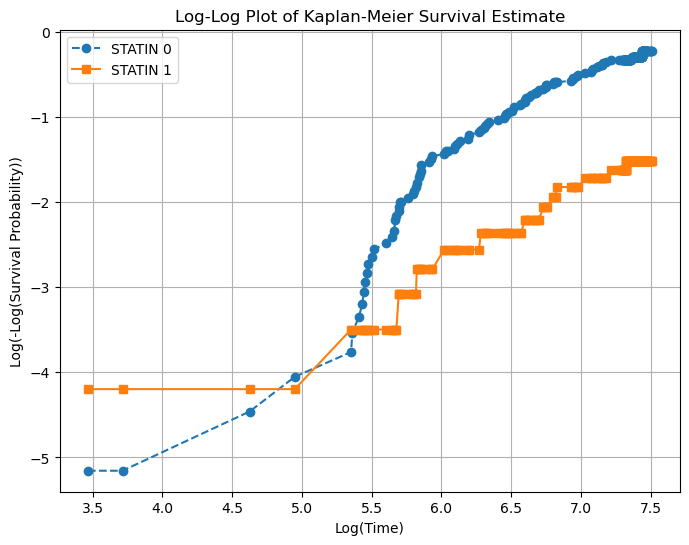

In [68]:

# 그래프 그리기
plt.figure(figsize=(8, 6))
plt.plot(loglog_df["Log(Time)"], loglog_df["STATIN 0"], label="STATIN 0", linestyle="--", marker="o")
plt.plot(loglog_df["Log(Time)"], loglog_df["STATIN 1"], label="STATIN 1", linestyle="-", marker="s")

plt.title("Log-Log Plot of Kaplan-Meier Survival Estimate")
plt.xlabel("Log(Time)")
plt.ylabel("Log(-Log(Survival Probability))")
plt.legend()
plt.grid(True)
plt.show()

In [72]:
loglog_df.head()

,Log(Time),STATIN 0,STATIN 1
1,3.465736,-5.156175,-4.197183
2,3.713572,-5.156175,-4.197183
3,4.624973,-4.460133,-4.197183
4,4.948760,-4.051760,-4.197183
5,5.351858,-3.761155,-3.496431


# 4. COX Regression

## 4-1) 분석1 - Cohort 없음

In [40]:
# 다변량 모델 구성
cox_cols = [ 'TIME', 'DTH', 'STATIN', 'AGE', 'RTX', 'SUR', 'CALC_CTRB_VTILE_FD', 'SIDO', 'CALC', 'AGEGP']
cox_df = main4[cox_cols].copy()

cox_df = cox_df.dropna()

In [42]:
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 0 to 240
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TIME                131 non-null    int64  
 1   DTH                 131 non-null    int64  
 2   STATIN              131 non-null    int64  
 3   AGE                 131 non-null    int64  
 4   RTX                 131 non-null    int64  
 5   SUR                 131 non-null    int64  
 6   CALC_CTRB_VTILE_FD  131 non-null    float64
 7   SIDO                131 non-null    float64
 8   CALC                131 non-null    int64  
 9   AGEGP               131 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 11.3 KB


In [44]:
# 범주형 변수 인코딩
cox_df_dummies = pd.get_dummies(cox_df, columns = ['SIDO', 'CALC', 'AGEGP'], drop_first = True)
cox_df_dummies.head()

,TIME,DTH,STATIN,AGE,RTX,SUR,CALC_CTRB_VTILE_FD,SIDO_2.0,CALC_2,AGEGP_2
0,1568,0,1,39,0,1,10.0,True,True,False
7,1464,0,1,51,0,1,10.0,True,True,False
14,1664,0,0,59,1,1,1.0,False,False,False
15,1485,0,1,68,1,0,8.0,True,True,True
20,858,1,1,66,1,1,10.0,False,True,True


In [52]:
# 다변량 Cox 모델 적합
cph = CoxPHFitter()
cph.fit(cox_df_dummies, duration_col='TIME', event_col='DTH')

<lifelines.CoxPHFitter: fitted with 131 total observations, 80 right-censored observations>

In [54]:
# 결과 출력
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 131 total observations, 80 right-censored observations>
             duration col = 'TIME'
                event col = 'DTH'
      baseline estimation = breslow
   number of observations = 131
number of events observed = 51
   partial log-likelihood = -226.40
         time fit was run = 2025-05-09 00:37:19 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
STATIN             -1.13      0.32      0.46           -2.03           -0.23                0.13                0.79
AGE                 0.01      1.01      0.02           -0.03            0.05                0.97                1.05
RTX                -0.70      0.50      0.36           -1.40            0.00                0.25                1.00
SUR                -0.33      0.72      0.32           -0.95            0.29                0.39                1.34
CALC_CTRB_VTILE_FD -0.02      0.98      0.09           -0.21            0.16                0.81                1.18
SIDO_2.0           -0.11      0.90      0.36           -0.82            0.61                0.44                1.84
CALC_2             -0.18      0.84      0.64           -1.44            1.08                0.24                2.94
AGEGP_2            -0.07      0.93      0.54           -1.12            0.98                0.33                2.66

                    cmp to     z    p  -log2(p)
covariate                                      
STATIN                0.00 -2.47 0.01      6.20
AGE                   0.00  0.56 0.57      0.80
RTX                   0.00 -1.95 0.05      4.29
SUR                   0.00 -1.04 0.30      1.75
CALC_CTRB_VTILE_FD    0.00 -0.23 0.82      0.29
SIDO_2.0              0.00 -0.29 0.77      0.37
CALC_2                0.00 -0.28 0.78      0.36
AGEGP_2               0.00 -0.13 0.89      0.16
---
Concordance = 0.68
Partial AIC = 468.79
log-likelihood ratio test = 21.88 on 8 df
-log2(p) of ll-ratio test = 7.60

<Axes: xlabel='log(HR) (95% CI)'>

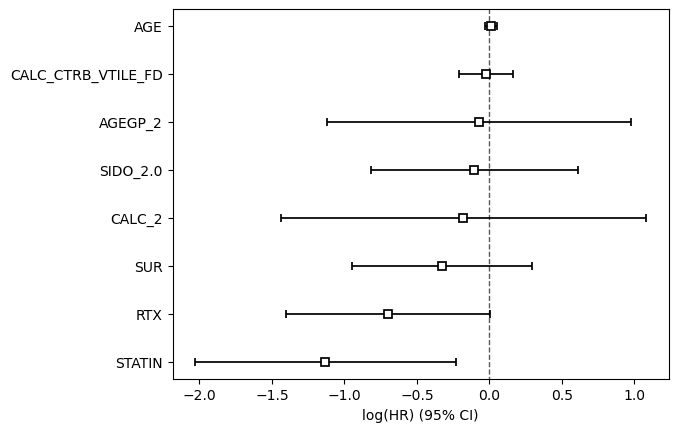

In [56]:
cph.plot()

In [25]:
main4.columns

Index(['SN_KEY', 'SEER_GRP', 'AGE', 'FDX', 'INDEX_Y', 'INDEX_MDY', 'STATIN',
       'DTH', 'DREGDATE', 'INDEX_AGE', 'SIDO_CD', 'CALC_CTRB_VTILE_FD', 'DYS',
       'RTX', 'SUR', 'DTH_MDY', 'TIME', 'SIDO', 'CALC', 'AGEGP'],
      dtype='object')

## 4-2) 분석1 - Cohort 있음

In [157]:
multi_cols = [ 'TIME', 'DTH', 'STATIN', 'AGE', 'RTX', 'SUR', 'CALC_CTRB_VTILE_FD', 'SIDO', 'CALC', 'AGEGP']
#['TIME', 'DTH', 'STATIN', 'AGEGP', 'RTX']

multi_cox_df = main4[multi_cols].copy()
multi_cox_df = multi_cox_df.dropna()

multi_cox_df.head()

,TIME,DTH,STATIN,AGE,RTX,SUR,CALC_CTRB_VTILE_FD,SIDO,CALC,AGEGP
0,1568,0,1,39,0,1,10.0,2.0,2,1
7,1464,0,1,51,0,1,10.0,2.0,2,1
14,1664,0,0,59,1,1,1.0,1.0,1,1
15,1485,0,1,68,1,0,8.0,2.0,2,2
20,858,1,1,66,1,1,10.0,1.0,2,2


In [62]:
# 설정: 코호트 나눌 컬럼 (SIDO 대신 성별, 흡연여부 등 가능)
cohort_col = 'STATIN'  # 여기를 자유롭게 바꿔서 코호트 기준 설정 가능

In [77]:
# 코호트별 반복
for cohort_value in cox_df[cohort_col].unique():
    print(f"\n===== 분석 코호트: {cohort_col} = {cohort_value} =====")
    
    # (1) 특정 코호트 데이터 추출
    cohort_df = cox_df[cox_df[cohort_col] == cohort_value]
    
    # (2) 다변량 분석을 위해 범주형 변수 더미화 (drop_first=True로 기준군 설정)
    #cohort_dummies = pd.get_dummies(cohort_df, columns=[], drop_first=True)

    # 코호트 기준 컬럼을 feature에서 제거
    cohort_dummies = cohort_df.drop(columns=[cohort_col], errors='ignore')
    
    # (3) 다변량 Cox 모델 학습
    cph2 = CoxPHFitter()
    try:
        cph2.fit(cohort_dummies, duration_col='TIME', event_col='DTH')
        # (4) 결과 출력
        print(cph2.summary)
        print(cph2.print_summary())
    except Exception as e:
        print(f"Error fitting model for {cohort_value}: {e}")


===== 분석 코호트: STATIN = 1 =====
                        coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                           
AGE                -0.041937   0.958930  0.080721       -0.200147   
RTX                -0.046736   0.954339  1.076648       -2.156928   
SUR                -1.435247   0.238057  0.949921       -3.297058   
CALC_CTRB_VTILE_FD -0.145134   0.864906  0.334415       -0.800576   
SIDO               -0.180624   0.834749  1.422643       -2.968952   
CALC                0.564721   1.758957  1.991713       -3.338964   
AGEGP               0.604024   1.829465  1.643870       -2.617902   

                    coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                      
AGE                       0.116273             0.818610             1.123302   
RTX                       2.063456             0.115680             7.873134   
SUR                       

<lifelines.CoxPHFitter: fitted with 38 total observations, 32 right-censored observations>
             duration col = 'TIME'
                event col = 'DTH'
      baseline estimation = breslow
   number of observations = 38
number of events observed = 6
   partial log-likelihood = -19.98
         time fit was run = 2025-05-09 01:02:11 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
AGE                -0.04      0.96      0.08           -0.20            0.12                0.82                1.12
RTX                -0.05      0.95      1.08           -2.16            2.06                0.12                7.87
SUR                -1.44      0.24      0.95           -3.30            0.43                0.04                1.53
CALC_CTRB_VTILE_FD -0.15      0.86      0.33           -0.80            0.51                0.45                1.67
SIDO               -0.18      0.83      1.42           -2.97            2.61                0.05               13.57
CALC                0.56      1.76      1.99           -3.34            4.47                0.04               87.22
AGEGP               0.60      1.83      1.64           -2.62            3.83                0.07               45.88

                    cmp to     z    p  -log2(p)
covariate                                      
AGE                   0.00 -0.52 0.60      0.73
RTX                   0.00 -0.04 0.97      0.05
SUR                   0.00 -1.51 0.13      2.93
CALC_CTRB_VTILE_FD    0.00 -0.43 0.66      0.59
SIDO                  0.00 -0.13 0.90      0.15
CALC                  0.00  0.28 0.78      0.36
AGEGP                 0.00  0.37 0.71      0.49
---
Concordance = 0.65
Partial AIC = 53.95
log-likelihood ratio test = 2.87 on 7 df
-log2(p) of ll-ratio test = 0.16

None

===== 분석 코호트: STATIN = 0 =====
                        coef  exp(coef)  se(coef)  coef lower 95%  \
covariate                                                           
AGE                 0.013266   1.013354  0.021987       -0.029829   
RTX                -0.745966   0.474276  0.400892       -1.531701   
SUR                -0.223730   0.799531  0.329827       -0.870180   
CALC_CTRB_VTILE_FD -0.015816   0.984308  0.102260       -0.216242   
SIDO               -0.069011   0.933316  0.386922       -0.827364   
CALC               -0.186345   0.829987  0.704581       -1.567299   
AGEGP              -0.076892   0.925990  0.572761       -1.199482   

                    coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%  \
covariate                                                                      
AGE                       0.056361             0.970612             1.057979   
RTX                       0.039768             0.216168             1.040570   
SUR                  

<lifelines.CoxPHFitter: fitted with 93 total observations, 48 right-censored observations>
             duration col = 'TIME'
                event col = 'DTH'
      baseline estimation = breslow
   number of observations = 93
number of events observed = 45
   partial log-likelihood = -187.96
         time fit was run = 2025-05-09 01:02:11 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
AGE                 0.01      1.01      0.02           -0.03            0.06                0.97                1.06
RTX                -0.75      0.47      0.40           -1.53            0.04                0.22                1.04
SUR                -0.22      0.80      0.33           -0.87            0.42                0.42                1.53
CALC_CTRB_VTILE_FD -0.02      0.98      0.10           -0.22            0.18                0.81                1.20
SIDO               -0.07      0.93      0.39           -0.83            0.69                0.44                1.99
CALC               -0.19      0.83      0.70           -1.57            1.19                0.21                3.30
AGEGP              -0.08      0.93      0.57           -1.20            1.05                0.30                2.85

                    cmp to     z    p  -log2(p)
covariate                                      
AGE                   0.00  0.60 0.55      0.87
RTX                   0.00 -1.86 0.06      3.99
SUR                   0.00 -0.68 0.50      1.01
CALC_CTRB_VTILE_FD    0.00 -0.15 0.88      0.19
SIDO                  0.00 -0.18 0.86      0.22
CALC                  0.00 -0.26 0.79      0.34
AGEGP                 0.00 -0.13 0.89      0.16
---
Concordance = 0.57
Partial AIC = 389.91
log-likelihood ratio test = 6.18 on 7 df
-log2(p) of ll-ratio test = 0.95

None


# 5. Schoenfeld 

In [81]:
# COX 학습이 수행된 이후에 Schoenfeld 잔차 검증 진행

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 131 total observations, 80 right-censored observations>
             duration col = 'TIME'
                event col = 'DTH'
      baseline estimation = breslow
   number of observations = 131
number of events observed = 51
   partial log-likelihood = -226.40
         time fit was run = 2025-05-09 00:37:19 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
STATIN             -1.13      0.32      0.46           -2.03           -0.23                0.13                0.79
AGE                 0.01      1.01      0.02           -0.03            0.05                0.97                1.05
RTX                -0.70      0.50      0.36           -1.40            0.00                0.25                1.00
SUR                -0.33      0.72      0.32           -0.95            0.29                0.39                1.34
CALC_CTRB_VTILE_FD -0.02      0.98      0.09           -0.21            0.16                0.81                1.18
SIDO_2.0           -0.11      0.90      0.36           -0.82            0.61                0.44                1.84
CALC_2             -0.18      0.84      0.64           -1.44            1.08                0.24                2.94
AGEGP_2            -0.07      0.93      0.54           -1.12            0.98                0.33                2.66

                    cmp to     z    p  -log2(p)
covariate                                      
STATIN                0.00 -2.47 0.01      6.20
AGE                   0.00  0.56 0.57      0.80
RTX                   0.00 -1.95 0.05      4.29
SUR                   0.00 -1.04 0.30      1.75
CALC_CTRB_VTILE_FD    0.00 -0.23 0.82      0.29
SIDO_2.0              0.00 -0.29 0.77      0.37
CALC_2                0.00 -0.28 0.78      0.36
AGEGP_2               0.00 -0.13 0.89      0.16
---
Concordance = 0.68
Partial AIC = 468.79
log-likelihood ratio test = 21.88 on 8 df
-log2(p) of ll-ratio test = 7.60


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 131 total observations, 80 right-censored observations>
         test_name = proportional_hazard_test

---
                         test_statistic    p  -log2(p)
AGE                km              0.31 0.58      0.79
                   rank            0.31 0.58      0.79
AGEGP_2            km              0.15 0.70      0.51
                   rank            0.15 0.70      0.51
CALC_2             km              0.05 0.82      0.28
                   rank            0.04 0.85      0.24
CALC_CTRB_VTILE_FD km              0.08 0.78      0.36
                   rank            0.10 0.76      0.40
RTX                km              0.56 0.45      1.14
                   rank            0.54 0.46      1.11
SIDO_2.0           km              3.91 0.05      4.38
                   rank            3.94 0.05      4.41
STATIN             km              4.85 0.03      5.17
                   rank            4.87 0.03      5.19
SUR                km              0.00 0.98      0.03
                   rank            0.00 0.98      0.03



1. Variable 'STATIN' failed the non-proportional test: p-value is 0.0274.

   Advice: with so few unique values (only 2), you can include `strata=['STATIN', ...]` in the call
in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'SIDO_2.0' failed the non-proportional test: p-value is 0.0471.

   Advice: with so few unique values (only 2), you can include `strata=['SIDO_2.0', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_no

[[<Axes: xlabel='rank-transformed time\n(p=0.0274)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0277)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5796)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5788)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4627)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4538)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9767)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9786)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7579)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7788)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0471)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0481)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8455)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8237)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7021)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7029)'>]]

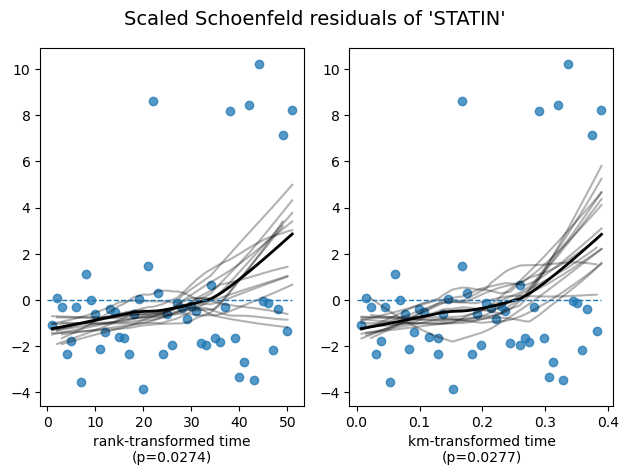

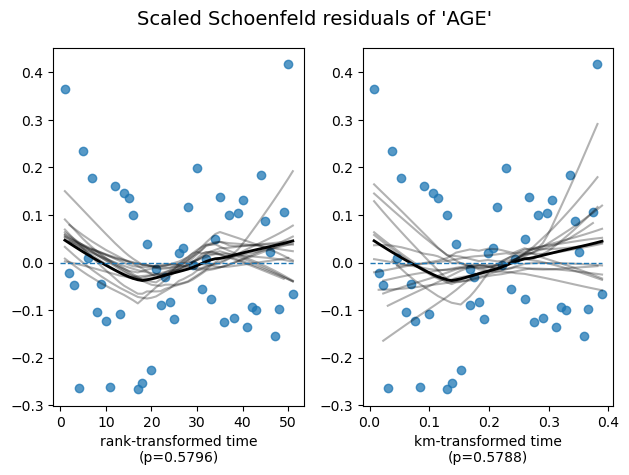

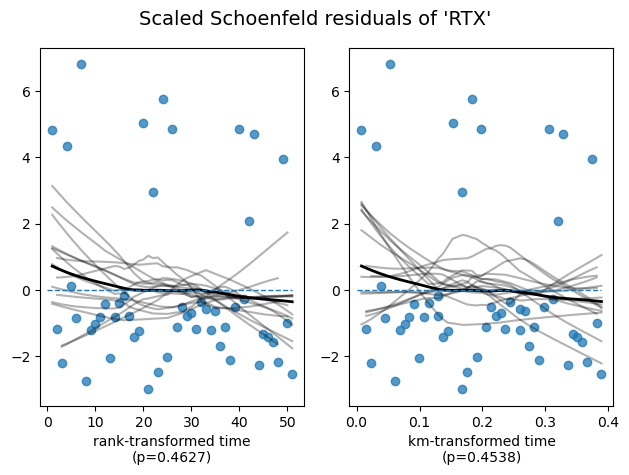

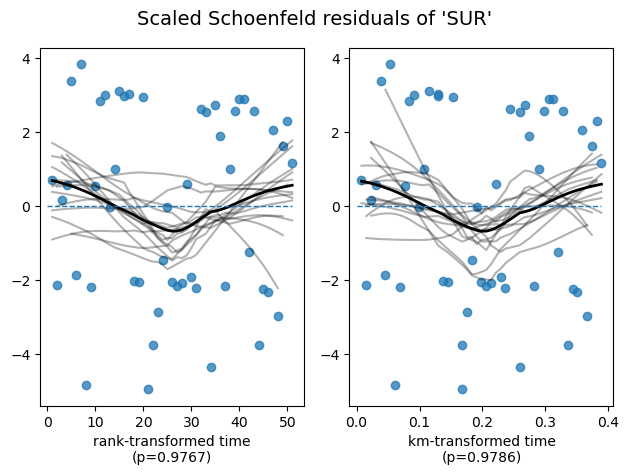

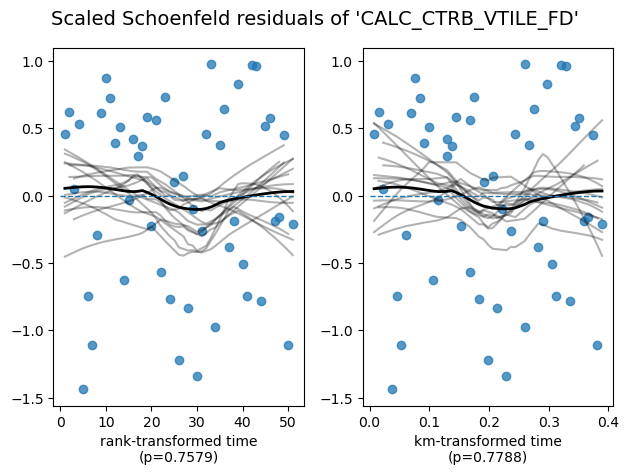

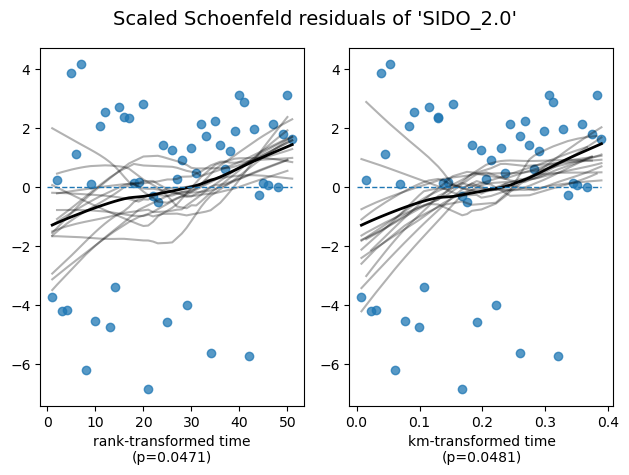

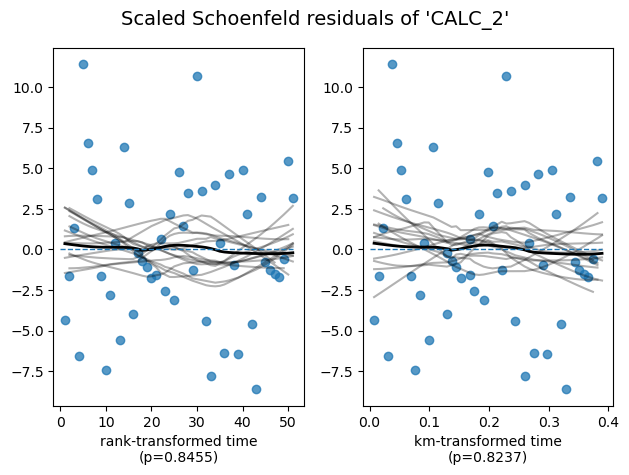

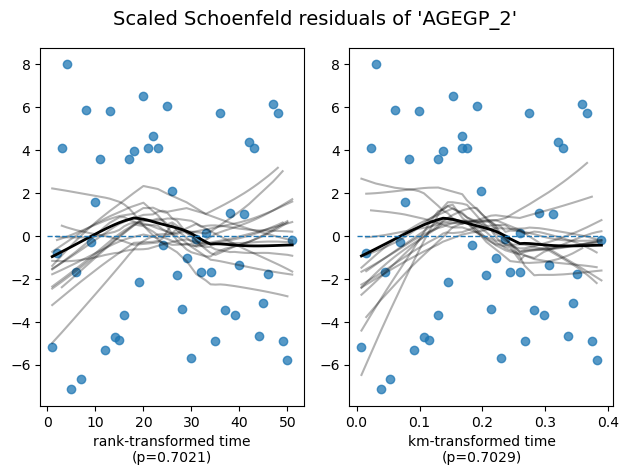

In [85]:
cph.check_assumptions(
    training_df=cox_df_dummies,  # Cox 모델에 사용한 데이터프레임
    p_value_threshold=0.05,
    show_plots=True,     # 변수별 그래프도 보고 싶을 경우
    columns=None         # None이면 전체 변수 대상으로 수행
)

In [87]:
# proportional_hazard_test() 함수로 수행
from lifelines.statistics import proportional_hazard_test

results = proportional_hazard_test(cph, cox_df_dummies, time_transform='rank')
results.print_summary()

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 131 total observations, 80 right-censored observations>
         test_name = proportional_hazard_test

---
                    test_statistic    p  -log2(p)
AGE                           0.31 0.58      0.79
AGEGP_2                       0.15 0.70      0.51
CALC_2                        0.04 0.85      0.24
CALC_CTRB_VTILE_FD            0.10 0.76      0.40
RTX                           0.54 0.46      1.11
SIDO_2.0                      3.94 0.05      4.41
STATIN                        4.87 0.03      5.19
SUR                           0.00 0.98      0.03

### Sampling

In [111]:
cox_df_sample = cox_df_dummies[['TIME', 'STATIN','DTH']] # 필요한 열만 추출
cox_df_sample.head()

,TIME,STATIN,DTH
0,1568,1,0
7,1464,1,0
14,1664,0,0
15,1485,1,0
20,858,1,1


In [119]:
cph_sample = CoxPHFitter()
cph_sample.fit(cox_df_sample, duration_col='TIME', event_col='DTH')

sample_result = proportional_hazard_test(cph_sample, cox_df_sample, time_transform='rank')
sample_result

<lifelines.StatisticalResult: proportional_hazard_test>
    time_transform = rank
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 131 total observations, 80 right-censored observations>
         test_name = proportional_hazard_test

---
        test_statistic    p  -log2(p)
STATIN            5.25 0.02      5.51

# 6. 모델 성능 평가

In [123]:
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 131 total observations, 80 right-censored observations>
             duration col = 'TIME'
                event col = 'DTH'
      baseline estimation = breslow
   number of observations = 131
number of events observed = 51
   partial log-likelihood = -226.40
         time fit was run = 2025-05-09 00:37:19 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
STATIN             -1.13      0.32      0.46           -2.03           -0.23                0.13                0.79
AGE                 0.01      1.01      0.02           -0.03            0.05                0.97                1.05
RTX                -0.70      0.50      0.36           -1.40            0.00                0.25                1.00
SUR                -0.33      0.72      0.32           -0.95            0.29                0.39                1.34
CALC_CTRB_VTILE_FD -0.02      0.98      0.09           -0.21            0.16                0.81                1.18
SIDO_2.0           -0.11      0.90      0.36           -0.82            0.61                0.44                1.84
CALC_2             -0.18      0.84      0.64           -1.44            1.08                0.24                2.94
AGEGP_2            -0.07      0.93      0.54           -1.12            0.98                0.33                2.66

                    cmp to     z    p  -log2(p)
covariate                                      
STATIN                0.00 -2.47 0.01      6.20
AGE                   0.00  0.56 0.57      0.80
RTX                   0.00 -1.95 0.05      4.29
SUR                   0.00 -1.04 0.30      1.75
CALC_CTRB_VTILE_FD    0.00 -0.23 0.82      0.29
SIDO_2.0              0.00 -0.29 0.77      0.37
CALC_2                0.00 -0.28 0.78      0.36
AGEGP_2               0.00 -0.13 0.89      0.16
---
Concordance = 0.68
Partial AIC = 468.79
log-likelihood ratio test = 21.88 on 8 df
-log2(p) of ll-ratio test = 7.60